# pyTelops Showcase

Full workflow for the Telops FAST M3k thermal camera:
discovery, configuration, live streaming, high-speed buffer recording, and visualization.

See the [README](README.rst) for installation and API reference.

## Setup

In [1]:
# # Firewall: allow inbound UDP for GVSP streaming (run once, needs admin)
# import sys, subprocess
# exe = sys.executable
# result = subprocess.run(
#     ["netsh", "advfirewall", "firewall", "show", "rule", "name=pyTelops-GVSP"],
#     capture_output=True, text=True)
# if "No rules match" in result.stderr or result.returncode != 0:
#     print(f"Adding firewall rule for: {exe}")
#     r = subprocess.run(
#         ["netsh", "advfirewall", "firewall", "add", "rule",
#          "name=pyTelops-GVSP", "dir=in", "action=allow",
#          "protocol=UDP", f"program={exe}"],
#         capture_output=True, text=True)
#     print("Done." if r.returncode == 0 else f"Failed (need admin?): {r.stderr.strip()}")
# else:
#     print("Firewall rule already exists.")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyTelops import Camera, discover

## 1. Discovery

Find cameras on the network via GVCP broadcast. Works regardless of camera IP.

In [3]:
cameras = discover()
for c in cameras:
    print(f"{c['manufacturer']} {c['model']} at {c['ip']} (serial: {c.get('serial', '?')})")

Telops Inc. TS-IR at 169.254.17.4 (serial: )


## 2. Connect

Auto-discovers the first camera. Handles stale sessions automatically.

In [4]:
cam = Camera()
cam.connect()
cam.info

Discovered: Telops Inc. TS-IR at 169.254.17.4


{'ip': '169.254.17.4',
 'width': 320,
 'height': 258,
 'integration_time_us': 30.0,
 'integration_time_auto': 'OFF',
 'frame_rate_hz': 20.0,
 'frame_rate_max_hz': 2932.340087890625,
 'calibration': 'RT',
 'trigger_mode': 'OFF',
 'power_state': 'ON',
 'temperature_c': 0.0,
 'buffer_mode': 'ON',
 'bad_pixel_replacement': True,
 'reverse_x': False,
 'reverse_y': False,
 'test_image': 'OFF',
 'frame_rate_mode': 'FIXED',
 'roi_offset': (0, 0)}

## 3. Configure

All settings are properties. Enums accept strings â€” no imports needed.

In [5]:
cam.integration_time = 30.0      # microseconds (set before frame_rate)
cam.frame_rate = 20.0          # Hz
cam.calibration_mode = "RT"      # radiometric temperature
cam.integration_time_auto = "off"

print(f"Frame rate:        {cam.frame_rate:.0f} Hz")
print(f"Frame rate max:    {cam.frame_rate_max:.0f} Hz")
print(f"Integration time:  {cam.integration_time:.1f} us")
print(f"Calibration:       {cam.calibration_mode.name}")
print(f"Resolution:        {cam.resolution}")

Frame rate:        20 Hz
Frame rate max:    2932 Hz
Integration time:  30.0 us
Calibration:       RT
Resolution:        (320, 258)


### Calibration

Load lens and temperature range info from the USB calibration data.
Select the right calibration for your lens and measurement range.

In [6]:
# Load calibration info from USB (adjust path to your camera)
cam.load_calibration_info(r"C:\Users\jasas\Desktop\Telops USB\Software and calibration tools\TEL-8050 Calibration Data")

# List available calibrations
cam.calibration_collections()

# Select by lens + target temperature
cam.calibration_load(lens="25mm", temp=25)

# Check active calibration
# cam.calibration_active()

Loaded calibration info: 13 .tsco files, 12 exposure time files from C:\Users\jasas\Desktop\Telops USB\Software and calibration tools\TEL-8050 Calibration Data
Loaded: MW 25mm FW0 (0-184 C)


{'index': 4,
 'posix': 1625659350,
 'lens': 'MW 25mm',
 'fw_position': 0,
 'temp_range': (0.0, 184.0)}

### Resolution

Reduce resolution for higher frame rates. Width step=64, height step=4.

In [7]:
print(f"Valid widths:  {cam.valid_widths}")
print(f"Valid heights: {cam.valid_heights[0]}...{cam.valid_heights[-1]} (step 4)")
print(f"Current:      {cam.resolution}, max fps: {cam.frame_rate_max:.0f} Hz")

# Example: half resolution for ~2x frame rate
# cam.resolution = (128, 130)
# print(f"Subwindow:    {cam.resolution}, max fps: {cam.frame_rate_max:.0f} Hz")
# cam.resolution = (320, 258)  # restore

Valid widths:  [64, 128, 192, 256, 320]
Valid heights: 6...258 (step 4)
Current:      (320, 258), max fps: 2932 Hz


## 4. Grab a frame

Single frame via live streaming. Header rows are stripped automatically.
Use percentile clipping to handle hot pixels.

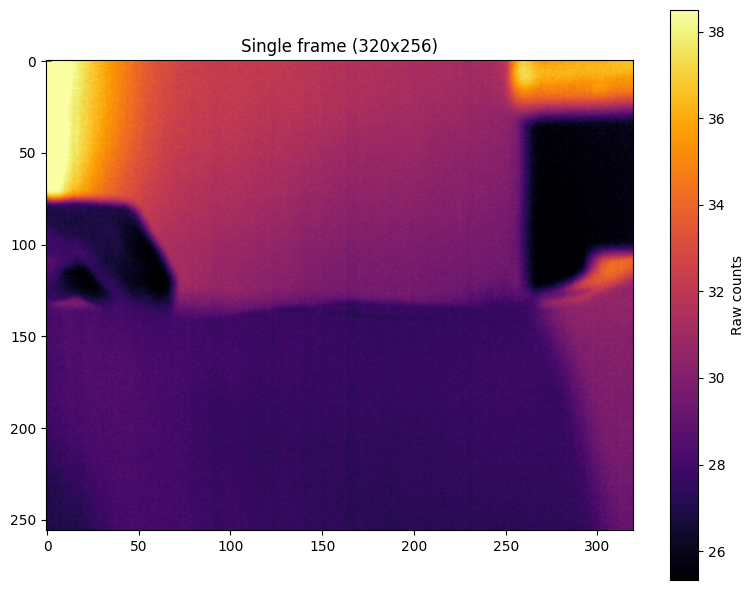

In [7]:
frame = cam.grab()
vmin, vmax = np.percentile(frame, [1, 99])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(frame, cmap='inferno', vmin=vmin, vmax=vmax)
ax.set_title(f'Single frame ({frame.shape[1]}x{frame.shape[0]})')
plt.colorbar(im, ax=ax, label='Temperature [°C]')
plt.tight_layout()
plt.show()

## 5. Acquire multiple frames (live streaming)

Streams directly to PC. Limited by Ethernet bandwidth (~49 fps).

In [ ]:
frames = cam.acquire(10)
print(f"Acquired: {frames.shape}")

## 6. Live viewer

Tkinter window with real-time thermal display, percentile normalization,
and colormap selector. Close the window to continue.

In [9]:
cam.live_view()

## 7. Buffer recording (high-speed)

The camera has a **16 GB internal buffer** that records at full sensor speed
(up to 3100 fps), independent of the Ethernet link.

### Configure

The buffer must be partitioned into fixed-size sequence slots before recording.

In [ ]:
# Ensure frame rate is set correctly for buffer recording
cam.frame_rate = 2000

cam.buffer_configure(
    n_sequences=1,
    duration=5.0,          # 5 seconds at current frame_rate
    moi_source="software",
)
print(f"Actual frame rate: {cam.frame_rate:.0f} Hz (max: {cam.frame_rate_max:.0f} Hz)")
print(cam.buffer_info())

Actual frame rate: 2000 Hz (max: 2932 Hz)
{'status': 'IDLE', 'n_sequences': 1, 'recorded': [0], 'total_bytes': 17179869184, 'free_bytes': 17179869184}


### Record

One call records all configured sequences: arms, fires MOI for each, waits for completion.

In [ ]:
cam.buffer_record();

### Download

Downloads recorded frames over Ethernet with a progress bar and data integrity check.

In [ ]:
data = cam.buffer_download(sequence=0)
print(f"Shape: {data.shape}, dtype: {data.dtype}, size: {data.nbytes / 1e6:.0f} MB")

In [ ]:
np.save('measurement_2000fps_5s.npy', data)
print(f"Saved to measurement_2000fps_5s.npy")

In [ ]:
cam.buffer_clear()

## 8. Visualize

### Sample frames

In [ ]:
FPS = cam.frame_rate  # frame rate used during buffer recording
n, h, w = data.shape
vmin, vmax = np.percentile(data, [1, 99])

indices = [0, n // 2, n - 1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, indices):
    im = ax.imshow(data[idx], cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(f'Frame {idx} (t={idx/FPS:.3f}s)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Temporal statistics

In [ ]:
mean_img = data.mean(axis=0)
std_img = data.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(mean_img, cmap='inferno',
                      vmin=np.percentile(mean_img, 1),
                      vmax=np.percentile(mean_img, 99))
axes[0].set_title('Temporal mean')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(std_img, cmap='hot')
axes[1].set_title('Temporal std')
plt.colorbar(im1, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

### Pixel time series

In [ ]:
py, px = h // 2, w // 2
t = np.arange(n) / FPS

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, data[:, py, px], linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature [°C]')
ax.set_title(f'Center pixel ({px}, {py})')
ax.set_xlim(0, t[-1])
plt.tight_layout()
plt.show()

## 9. Disconnect

In [ ]:
cam.disconnect()
print(cam.state)